In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV , StratifiedKFold, cross_val_score , cross_validate
from sklearn.linear_model import LinearRegression, Lasso , Ridge , ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import OneHotEncoder , LabelEncoder
from sklearn.compose import ColumnTransformer
print("All libraries have been imported successfully")

All libraries have been imported successfully


In [ ]:
# Here My data is generated
np.random.seed(42)
n = 1000

# Generate features (same as before)
area = np.random.randint(1000, 6000, n)
rooms = np.random.randint(1, 8, n)
distance = np.random.randint(1, 30, n)  # fixed typo: distant -> distance
age = np.random.randint(1, 50, n)
neighborhood = np.random.choice(["Rural", "Downtown", "Suburb"], n)
house_type = np.random.choice(["Apartment", "Townhouse", "Detached"], n)
renovated = np.random.choice(["Yes", "No"], n)


In [ ]:

#Note np.where(condition , True , False)
neighborhood_multiplier = np.where(neighborhood == "Rural", 1.0,
                          np.where(neighborhood == "Downtown", 1.5, 1.2))

house_type_multiplier = np.where(house_type == "Apartment", 1.1,
                        np.where(house_type == "Townhouse", 1.3, 1.5))

renovated_multiplier = np.where(renovated == "Yes", 1.25, 1.0)

# Base price calculation with more realistic coefficients
base_price = (
    area * 100 +           # Area contributes significantly
    rooms * 15000 +        # Each room adds value
    -distance * 2000 +     # Distance from center reduces price
    -age * 1000 +          # Older houses are cheaper
    100000                 # Base value for any house
)


# Apply multipliers
price = base_price * neighborhood_multiplier * house_type_multiplier * renovated_multiplier

# Reduced noise (only 1% instead of 5%)
noise = np.random.normal(loc=0, scale=price * 0.01, size=n)
price += noise

# Ensure minimum price
price = np.maximum(price, 50000)



price = np.maximum(price, 20000)



In [ ]:
# My Data Frame is Created here
data = {
      "Area": area,
      "Rooms": rooms,
      "Age": age,
      "CenterDistMile":distance, 
      "Neighbors": neighborhood,
      "Type of House":house_type,
      "Renovated": renovated,   
      "Price": price.astype(int) # This is the target price
}


df = pd.DataFrame(data)

df.head(5)

,Area,Rooms,Age,CenterDistMile,Neighbors,Type of House,Renovated,Price
0,1860,4,46,3,Downtown,Apartment,Yes,606649
1,4772,1,19,22,Suburb,Townhouse,No,825974
2,4092,2,22,14,Suburb,Apartment,No,642503
3,1466,3,24,16,Rural,Detached,Yes,435687
4,5426,6,45,10,Rural,Detached,Yes,1255792


In [ ]:
# 1️⃣Adding missing values:

size = int(0.15 * n) # 0.15 * 1000 = 150 features are choosen

nan_indices_room = np.random.choice(df.index , size= size, replace = False)

nan_indices_Thouse = np.random.choice(df.index, size = size , replace = False)

df.loc[nan_indices_room , "Rooms"] = np.nan # this line finds each entity by labels ==>df.loc

df.iloc[nan_indices_Thouse , 5] = np.nan # this line finds each entity by integr position ==>df.iloc

#2️⃣ Adding outliers to the dataset

outliers = 50 

outlier_indices_price = np.random.choice(df.index, size= outliers , replace=False)

df.iloc[outlier_indices_price , -1] = df.iloc[outlier_indices_price , -1] * 10

outlier_indices_Dist = np.random.choice(df.index , size= size , replace= False)

df.loc[outlier_indices_Dist, "CenterDistMile"] = df.loc[outlier_indices_Dist, "CenterDistMile"] * 10
df.sample(10)

,Area,Rooms,Age,CenterDistMile,Neighbors,Type of House,Renovated,Price
510,1732,6.0,38,110,Suburb,Detached,No,540384
365,5752,1.0,15,7,Rural,Apartment,No,739347
608,3956,2.0,47,19,Downtown,NaN,Yes,1086270
712,1899,NaN,5,28,Rural,Detached,No,456057
848,2673,4.0,47,180,Suburb,Detached,No,607120
35,4890,1.0,11,6,Suburb,Detached,No,1037303
561,2214,2.0,39,20,Suburb,Detached,No,491881
482,1728,1.0,19,20,Downtown,NaN,Yes,473046
967,4531,NaN,13,7,Suburb,Apartment,No,7965250
817,1467,6.0,39,17,Suburb,Apartment,No,346912


In [ ]:
# 3️⃣ Now cleaning the data
# Cleaning the "Rooms" and "Type of hosue" columns:
df_Rooms = df["Rooms"].median() # Median is used only for Numerical values
df_Thouse = df["Type of House"].mode().iloc[0]# mode is used only for categorical values

df["Rooms"] = df["Rooms"].fillna(df_Rooms)

df["Type of House"]= df["Type of House"].fillna(df_Thouse)
df.sample(20)


,Area,Rooms,Age,CenterDistMile,Neighbors,Type of House,Renovated,Price
640,2668,3.0,30,3,Downtown,Detached,No,848774
782,5206,4.0,4,17,Downtown,Detached,Yes,1751373
992,5662,4.0,23,24,Rural,Apartment,Yes,908618
181,3327,1.0,12,25,Downtown,Apartment,Yes,8052840
280,1016,5.0,30,17,Downtown,Apartment,Yes,433915
498,5491,2.0,45,1,Downtown,Detached,Yes,1762430
197,1146,6.0,15,9,Downtown,Townhouse,No,528440
169,4474,4.0,21,25,Suburb,Detached,Yes,1285516
32,2528,5.0,6,280,Suburb,Detached,No,672239
456,1825,3.0,48,16,Suburb,Detached,Yes,563094


In [ ]:

# Label Endoding for My renovated feature (Yes or NO)
Lencoder = LabelEncoder() # we use label encoding to turn Target column to numerical varaible 
df["Labeled-renovated"] = Lencoder.fit_transform(df["Renovated"])

# Createa the transformer 😎😎

categorical_columns_ = ["Type of House","Neighbors"]
ct = ColumnTransformer(transformers=[("one_encoder",
                                     OneHotEncoder(sparse_output=False,drop="first"),
                                     categorical_columns_)],
                       remainder="passthrough")

one_encoded_array = ct.fit_transform(df)
column_names = ct.get_feature_names_out()
one_encoded_df = pd.DataFrame(one_encoded_array, columns= column_names )
encoded_df = one_encoded_df.iloc[:,0:5]
final_df = pd.concat([df,encoded_df],axis=1)
final_df["Target (Price)"] = final_df["Price"]
final_df.drop(columns="Price",axis=1, inplace=True)
final_df

,Area,Rooms,Age,CenterDistMile,Neighbors,Type of House,Renovated,Labeled-renovated,one_encoder__Type of House_Detached,one_encoder__Type of House_Townhouse,one_encoder__Neighbors_Rural,one_encoder__Neighbors_Suburb,remainder__Area,Target (Price)
0,1860,4.0,46,3,Downtown,Apartment,Yes,1,0.0,0.0,0.0,0.0,1860,606649
1,4772,1.0,19,220,Suburb,Detached,No,0,1.0,0.0,0.0,1.0,4772,825974
2,4092,2.0,22,14,Suburb,Apartment,No,0,0.0,0.0,0.0,1.0,4092,642503
3,1466,4.0,24,16,Rural,Detached,Yes,1,1.0,0.0,1.0,0.0,1466,435687
4,5426,4.0,45,10,Rural,Detached,Yes,1,1.0,0.0,1.0,0.0,5426,1255792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2332,7.0,12,19,Suburb,Detached,Yes,1,1.0,0.0,0.0,1.0,2332,882855
996,1201,7.0,31,28,Downtown,Detached,Yes,1,1.0,0.0,0.0,0.0,1201,655126
997,4507,7.0,14,28,Rural,Townhouse,Yes,1,0.0,1.0,1.0,0.0,4507,940396
998,5212,3.0,34,19,Suburb,Apartment,Yes,1,0.0,0.0,0.0,1.0,5212,971029


In [ ]:
#4️⃣ Standardizing the feature
# ! Data Leakage is a thread 
scale = StandardScaler()
categorical_columns = ["Type of House","Renovated","Neighbors"]
target_column = ["Target (Price)"]
# Data is split therefore no leackage happens
X = final_df.drop(columns=target_column + categorical_columns , axis = 1) # axis = 1 means the entire column
y = final_df[target_column].squeeze() 
#  y = df[target_colummn] ==> Wrong becasue the target should be 1D array and not 2D,
#  2D is used for Training and X features,
#  That's why we use squeeze() it transform a 2D array to 1D array
#* Note: Always split your data first then scale them in order to avoid dataleakage

X_train , X_test , y_train , y_test = train_test_split(X , y, test_size= 0.3 , random_state= 42)

y_truth = y_test

X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test) # Do not fit your test data=> It leads to data leakage 



In [ ]:
#  -----Dimensions Reduction-----

# 1️⃣PCA 
pca = PCA(n_components=2,svd_solver="auto", random_state= 42)
pca_fit =pca.fit_transform(X_train_scaled)

In [ ]:
# 2️⃣t-SNE

tsne = TSNE(n_components= 2,perplexity=20,random_state=42 , max_iter=1000)
tsne_fit = tsne.fit_transform(X_train_scaled)



In [ ]:
# 3️⃣UMAP
umap_model = UMAP(n_neighbors=15 ,n_components=2, metric="euclidean",n_epochs=200 , learning_rate=1,n_jobs=-1)
umap_fit = umap_model.fit_transform(X_train_scaled)


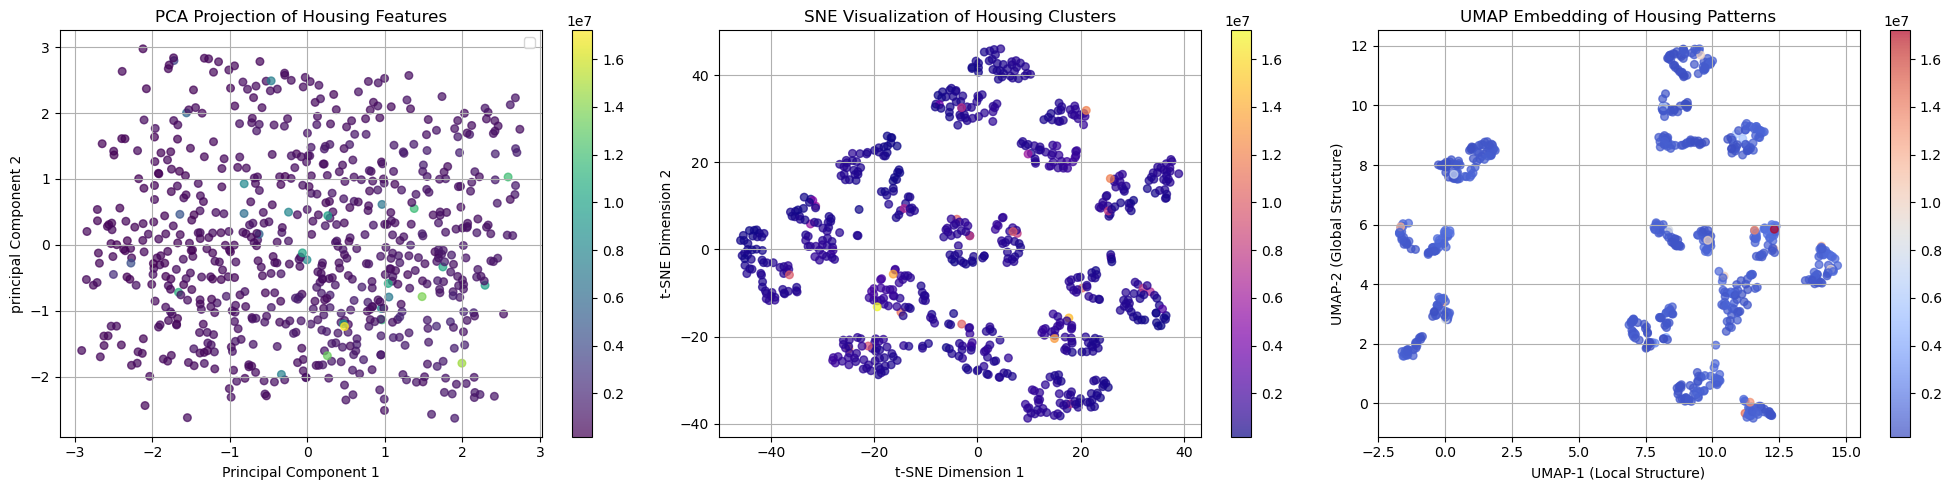

In [ ]:
# 🅰️ Comparison Between PCA / t-SNE and UMAP

fig , axes = plt.subplots(1,3,figsize=(20,5))

pca_scatter = axes[0].scatter(pca_fit[:,0], pca_fit[:,1],
                              s=30, alpha=0.7,
                              c=y_train, cmap="viridis")
axes[0].set_title("PCA Projection of Housing Features")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("principal Component 2")
axes[0].legend(())
axes[0].grid(True)
fig.colorbar(pca_scatter, ax=axes[0])

tsne_scatter = axes[1].scatter(tsne_fit[:,0],
                               tsne_fit[:,1],
                               s= 30,
                               alpha=0.7,
                               c=y_train, cmap="plasma")

axes[1].set_title("SNE Visualization of Housing Clusters")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].grid(True)
fig.colorbar(tsne_scatter,ax=axes[1])

umap_scatter = axes[2].scatter(umap_fit[:,0],
                               umap_fit[:,1],
                               s=30,
                               alpha=0.7,
                               c=y_train, 
                               cmap="coolwarm")
axes[2].set_title("UMAP Embedding of Housing Patterns")
axes[2].set_xlabel("UMAP-1 (Local Structure)")
axes[2].set_ylabel("UMAP-2 (Global Structure)")
axes[2].grid(True)
fig.colorbar(umap_scatter,ax=axes[2])

plt.tight_layout()
plt.show()

In [ ]:

# Creating LInear regression 
linear_model = LinearRegression()

linear_fit_model = linear_model.fit(X_train_scaled, y_train)

y_pre = linear_fit_model.predict(X_test_scaled)

test_score = linear_fit_model.score(X_test_scaled , y_test) # score uses r2 score for regression models and accuracy for classification 

In [ ]:
def Evaluation_Model(X_train_scaled , X_test_scaled , y_train , y_test):
    
    # Check Lasso regression or L1 regularization:
# it equaly penelize L1 norm which is absolute value of coeficent  and it shirnks them to Zero but Rudge regression or L2 regression can't do it
    lass_model = Lasso()
    lass_model.fit(X_train_scaled , y_train)
    lass_pre = lass_model.predict(X_test_scaled)
    lass_score_test = lass_model.score(X_test_scaled,y_test)
    
    # Check the Ridge Regression or L2 reqularization  result
    ridge_model = Ridge()
    ridge_model.fit(X_train_scaled, y_train)
    ridge_pre = ridge_model.predict(X_test_scaled)
    ridge_score_test = ridge_model.score(X_test_scaled , y_test)
    
    # Check the Elastic L1 and L2 regression outcome: 
    elastic_model = ElasticNet()
    elastic_model.fit(X_train_scaled , y_train)
    elastic_pre = elastic_model.predict(X_test_scaled)
    elastic_score = elastic_model.score(X_test_scaled , y_test)
    
    result = {"Model": ["Lasso Model", "Ridge Model", "ElasticNet Model"],
          "Final Score": [lass_score_test , ridge_score_test ,elastic_score ]}
    result_df = pd.DataFrame(result)
    result_df.sort_values(ascending=False, by="Final Score", inplace=True)
    
    return result_df

Evaluation_Model(X_train_scaled , X_test_scaled , y_train , y_test)

,Model,Final Score
2,ElasticNet Model,0.036843
1,Ridge Model,0.035107
0,Lasso Model,0.035069


In [ ]:
def regression_results(y_truth , y_pre, model = None , y_test = None , X_test = None):
      
      mse = mean_squared_error(y_truth, y_pre)
      mae = mean_absolute_error(y_truth, y_pre)
      rmse = np.sqrt(mean_squared_error(y_truth,y_pre))
      r2 = r2_score(y_truth, y_pre)
      results = f"""
      Mean Squared Error: {mse:.2f}
      Mean Absolute Error: {mae:.2f}
      Root Mean Squared Error: {rmse:.2f}
      R² Score: {r2:.2f}
      """
      
      # Information of the dataset
      if model is not None:
            results += f"Slope :{model.coef_}"
            results += f"Intercept :{model.intercept_}"
      
      # Score of the model 
      if model is not None and y_test is not None and X_test is not None:
            results += f"Score: {model.score(X_test , y_test )}"
      return results

In [ ]:
# ---- KNN regression 
Knn = KNeighborsRegressor(n_neighbors= 5)
Knn_model = Knn.fit(X_train_scaled , y_train)
Knn_pre = Knn.predict(X_test_scaled)

Knn_r2 = r2_score(y_test ,Knn_pre)
Knn_mse = mean_squared_error(y_test ,Knn_pre)
Knn_mae = mean_absolute_error(y_test ,Knn_pre)
data_knn = {
    "Metric": ["R2 score", "MSE", "MAE"],
    "Value": [Knn_r2, Knn_mse, Knn_mae]
}
Knn_df = pd.DataFrame(data_knn)
Knn_df

,Metric,Value
0,R2 score,-1.454472e-01
1,MSE,4.461861e+12
2,MAE,9.068828e+05


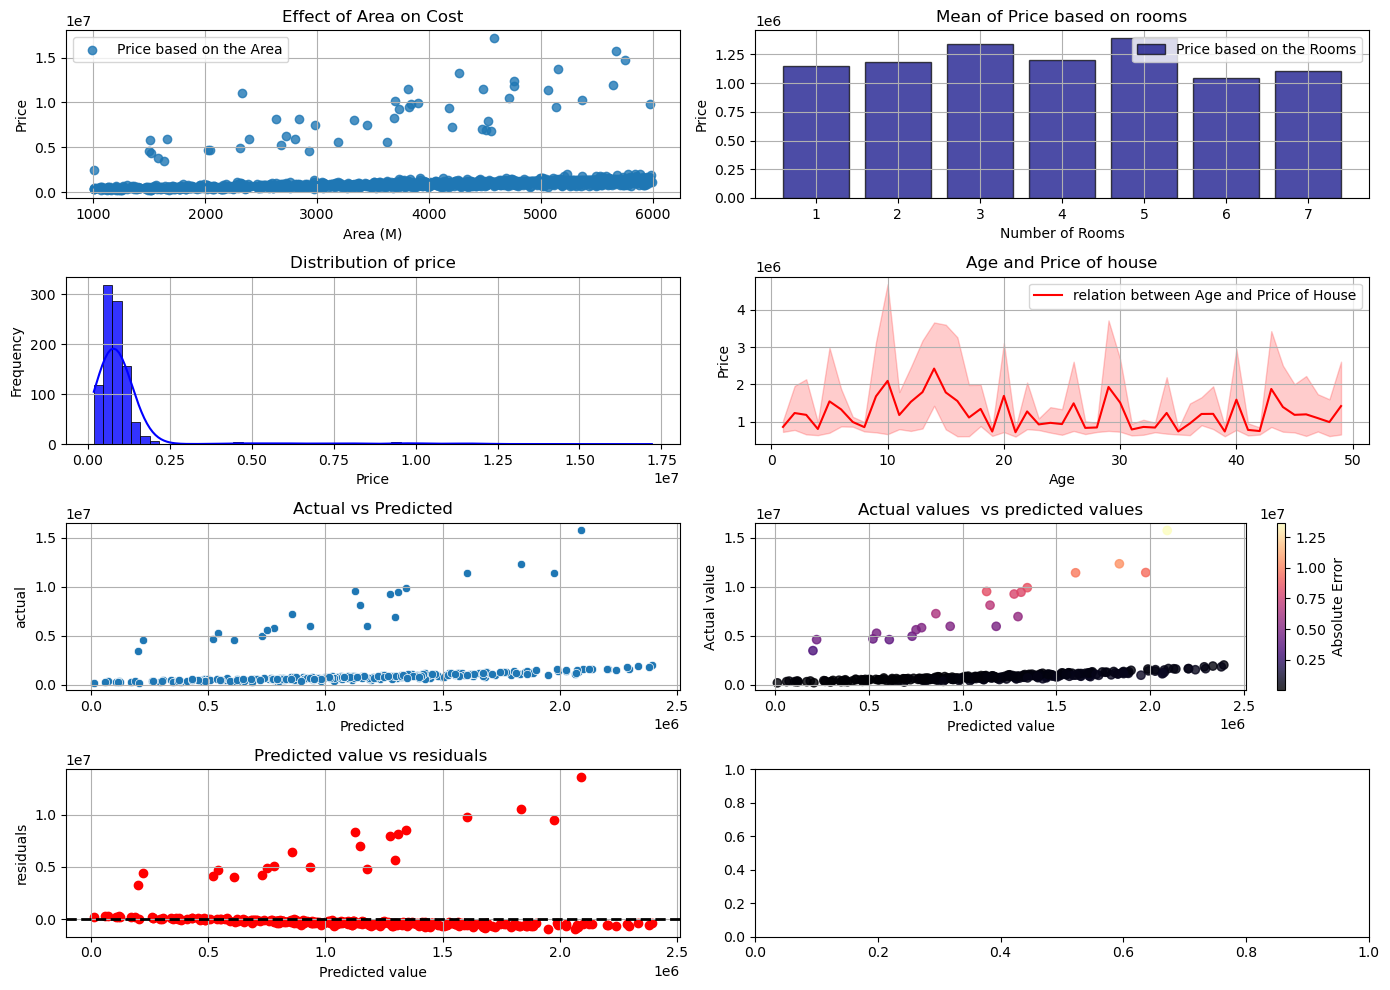

In [ ]:

fig , axes = plt.subplots(4, 2, figsize=(14,10))


sns.regplot(data=final_df,x=final_df["Area"],y=final_df["Target (Price)"],
                  label="Price based on the Area",
                  ax= axes[0,0])


axes[0,0].set_title("Effect of Area on Cost")
axes[0,0].set_xlabel("Area (M)")
axes[0,0].set_ylabel("Price")
axes[0,0].grid(True)
axes[0,0].legend()

room_price = final_df.groupby("Rooms")[ "Target (Price)"].mean()

axes[0,1].bar(room_price.index ,room_price.values ,
              edgecolor="black",
              color="navy",
              label="Price based on the Rooms",
              alpha= 0.7)
axes[0,1].set_title("Mean of Price based on rooms")
axes[0,1].set_xlabel("Number of Rooms")
axes[0,1].set_ylabel("Price")
axes[0,1].grid(True)
axes[0,1].legend()


sns.histplot(final_df["Target (Price)"],bins=60 , kde =True , color="blue", ax = axes[1,0], alpha = 0.8)
axes[1,0].set_title("Distribution of price")
axes[1,0].set_xlabel("Price")
axes[1,0].set_ylabel("Frequency")
axes[1,0].grid(True)



sns.lineplot(x=df["Age"], y=final_df["Target (Price)"] , color= "red", label="relation between Age and Price of House", ax=axes[1,1])
axes[1,1].set_title("Age and Price of house")
axes[1,1].set_xlabel("Age")
axes[1,1].set_ylabel("Price")
axes[1,1].grid(True)



sns.scatterplot(x=y_pre , y=y_test, ax=axes[2,0])
axes[2,0].set_title("Actual vs Predicted")
axes[2,0].set_xlabel("Predicted")
axes[2,0].set_ylabel("actual")
axes[2,0].grid(True)


# Calculate the errors :
residuals = y_test - y_pre
errors = np.abs(y_test - y_pre)
# Create predicted vs actual plots
scatter = axes[2,1].scatter(y_pre ,y_test,c=errors, cmap="magma", alpha= 0.8)
axes[2,1].set_title("Actual values  vs predicted values")
axes[2,1].set_xlabel("Predicted value")
axes[2,1].set_ylabel("Actual value")
axes[2,1].grid(True)
# Create my color bar ==> this feature is only used for numerical datasets
cbar = plt.colorbar(scatter ,ax = axes[2,1] )
cbar.set_label("Absolute Error")

# Create my residual plots 
"""I need residuals ✅
      y_test and y_pre ✅
      axhline ✅ and scatter✅
      scatter should be really scattered
      scatter object not requierd why ==> We do not need a colorbar"""
      
      
axes[3,0].scatter(y_pre, residuals,color="red")
axes[3,0].axhline(y = 0 , linestyle= "--", color="black",lw=2)
axes[3,0].set_title("Predicted value vs residuals ")
axes[3,0].set_xlabel("Predicted value")
axes[3,0].set_ylabel("residuals")
axes[3,0].grid(True)


plt.tight_layout()
plt.show()



AttributeError: Rectangle.set() got an unexpected keyword argument 's'

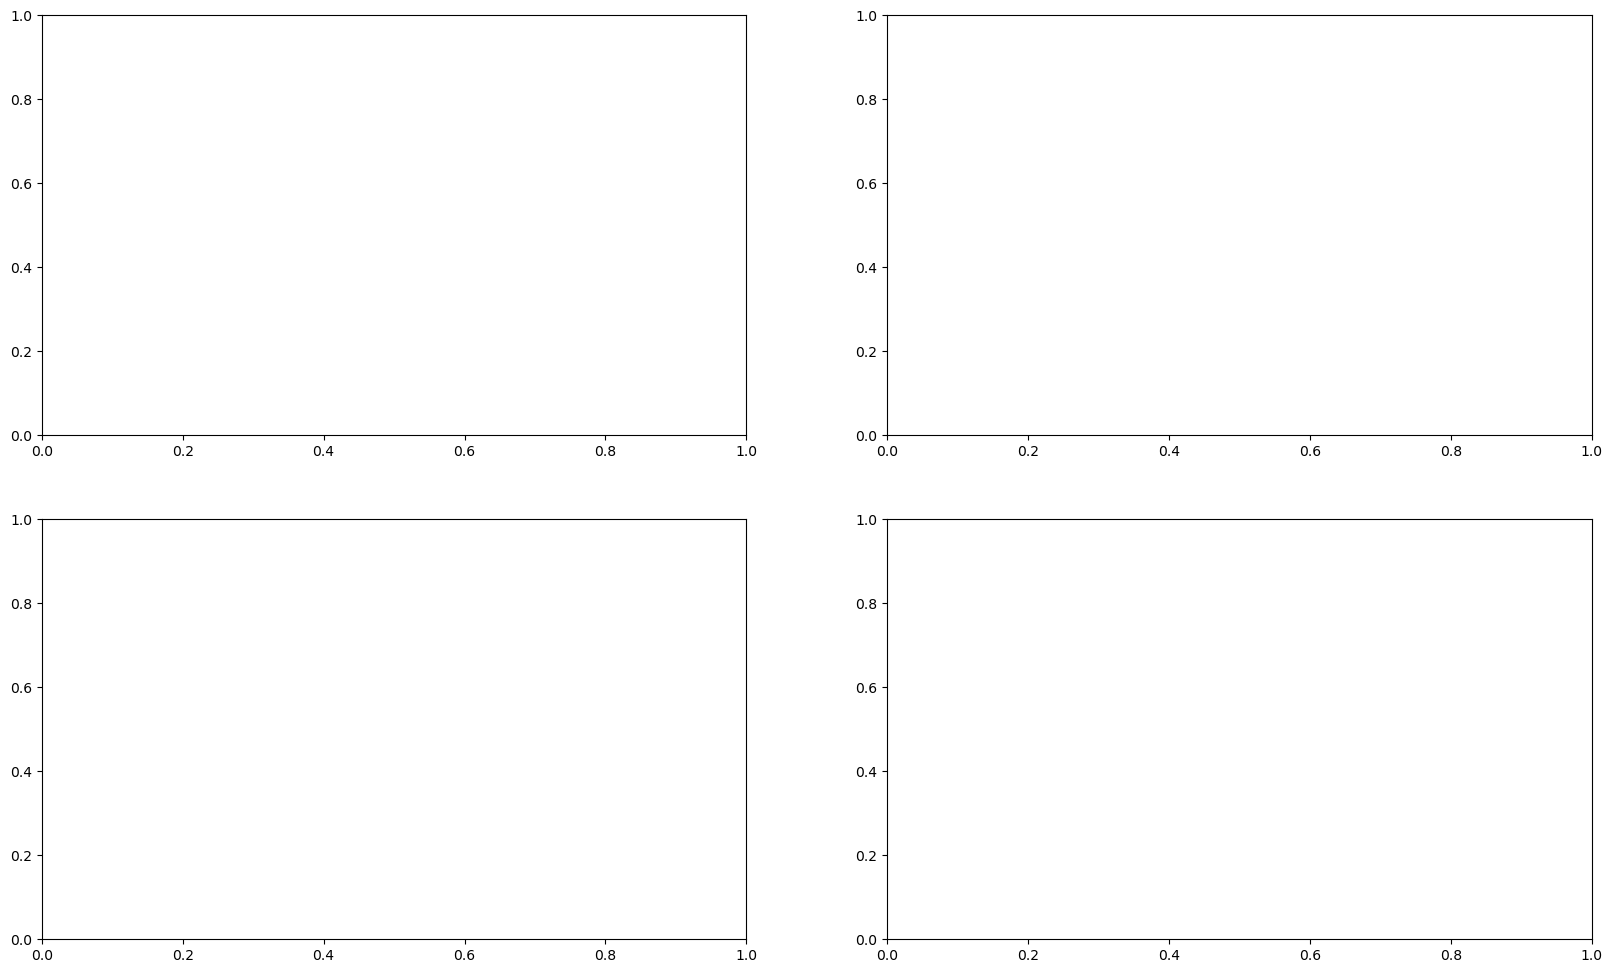

In [ ]:
# Plot of each feature vs Price
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1️⃣ CenterDistMile vs Price
axes[0,0].bar(final_df["CenterDistMile"], df["Price"], s=50, alpha=0.7, edgecolor="black", color="Navy")
axes[0,0].set_title("Price vs Distance from Downtown")
axes[0,0].set_xlabel("Distance from Downtown (Mile)")
axes[0,0].set_ylabel("Price ($)")
axes[0,0].grid(True)

# 2️⃣ Area vs Price
axes[0,1].scatter(final_df["Area"], final_df["Target (Price)"], s=50, alpha=0.7, edgecolor="black", color="Green")
axes[0,1].set_title("Price vs Area of the House")
axes[0,1].set_xlabel("Area (sq ft)")
axes[0,1].set_ylabel("Price ($)")
axes[0,1].grid(True)

# 3️⃣ Rooms vs Price
axes[1,0].scatter(final_df["Rooms"], final_df["Target (Price)"],alpha=0.7, edgecolor="black", color="Orange")
axes[1,0].set_title("Price vs Number of Rooms")
axes[1,0].set_xlabel("Number of Rooms")
axes[1,0].set_ylabel("Price ($)")
axes[1,0].grid(True)

# 4️⃣ Age vs Price
axes[1,1].scatter(final_df["Age"], final_df["Target (Price)"], s=50, alpha=0.7, edgecolor="black", color="Red")
axes[1,1].set_title("Price vs Age of the House")
axes[1,1].set_xlabel("Age (Years)")
axes[1,1].set_ylabel("Price ($)")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()


Training data shape: (700, 10)
Feature names: ['Area', 'Rooms', 'Age', 'CenterDistMile', 'Labeled-renovated', 'one_encoder__Type of House_Detached', 'one_encoder__Type of House_Town house', 'one_encoder__Neighbors_Rural', 'one_encoder__Neighbors_Suburb', 'remainder__Area']

PCA ANALYSIS


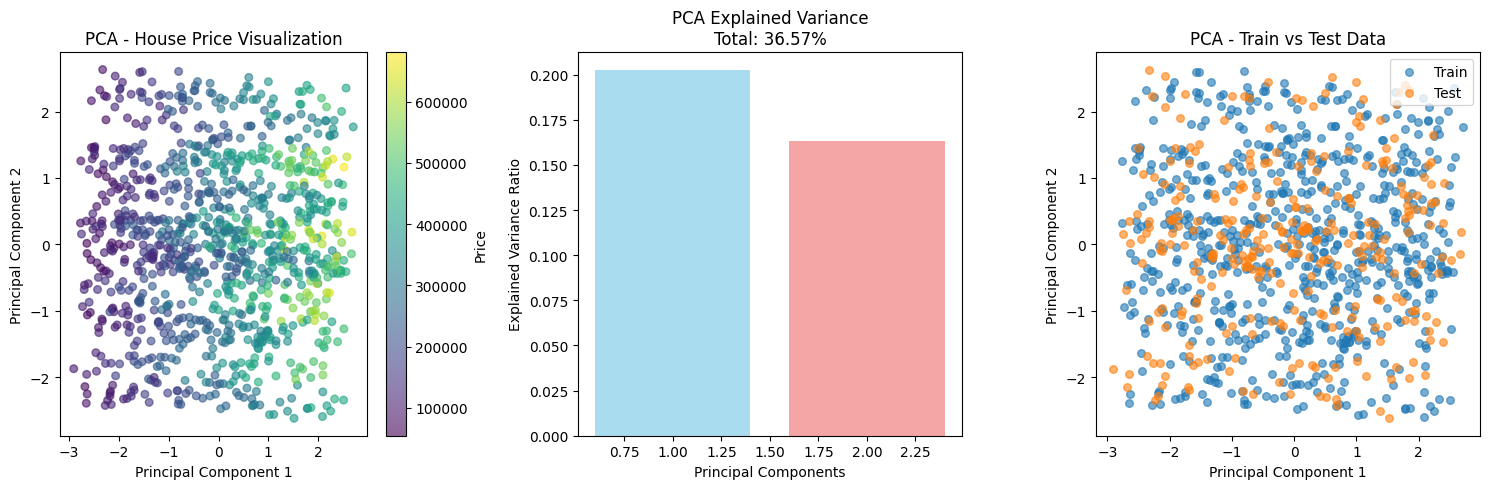

PCA Explained Variance Ratio: [0.20231716 0.16342041]
Total Variance Explained by 2 components: 36.57%

t-SNE ANALYSIS


d:\Python\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


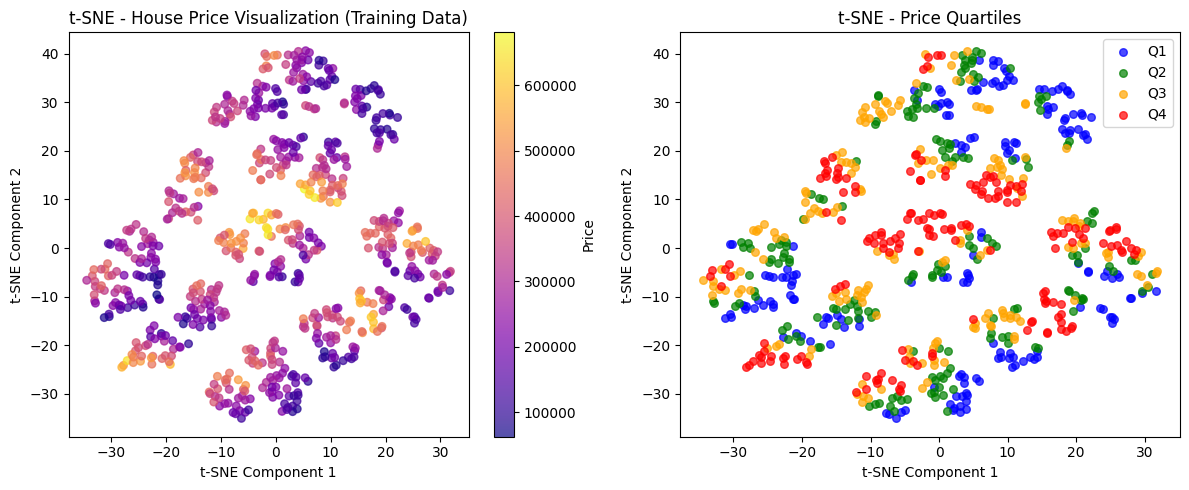


UMAP ANALYSIS


d:\Python\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


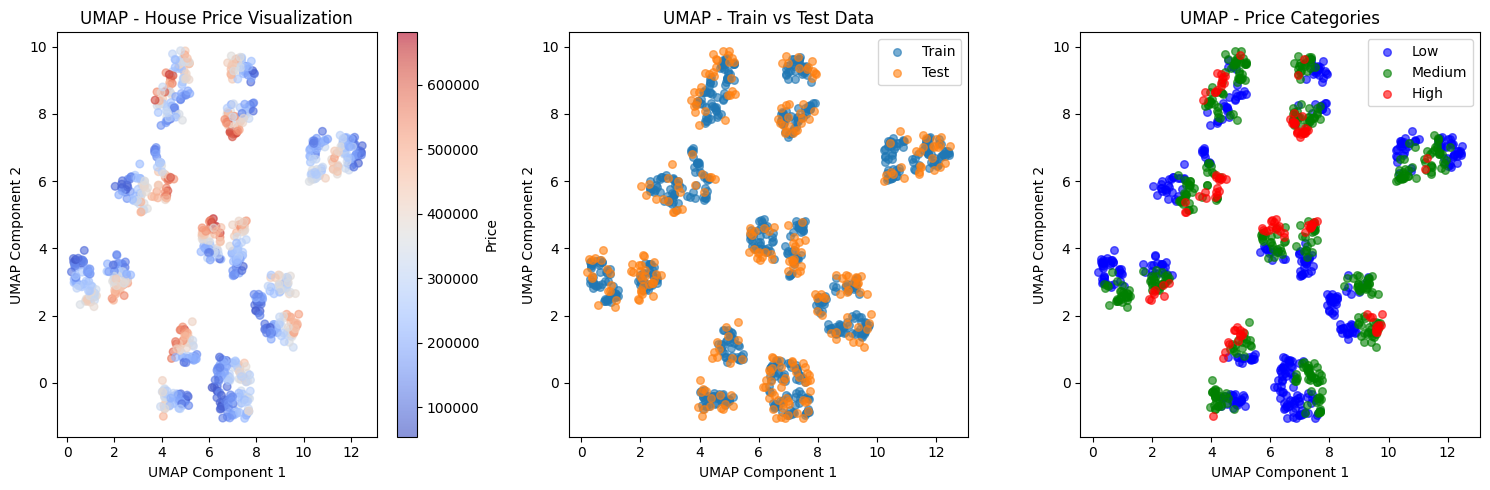


COMPARATIVE ANALYSIS


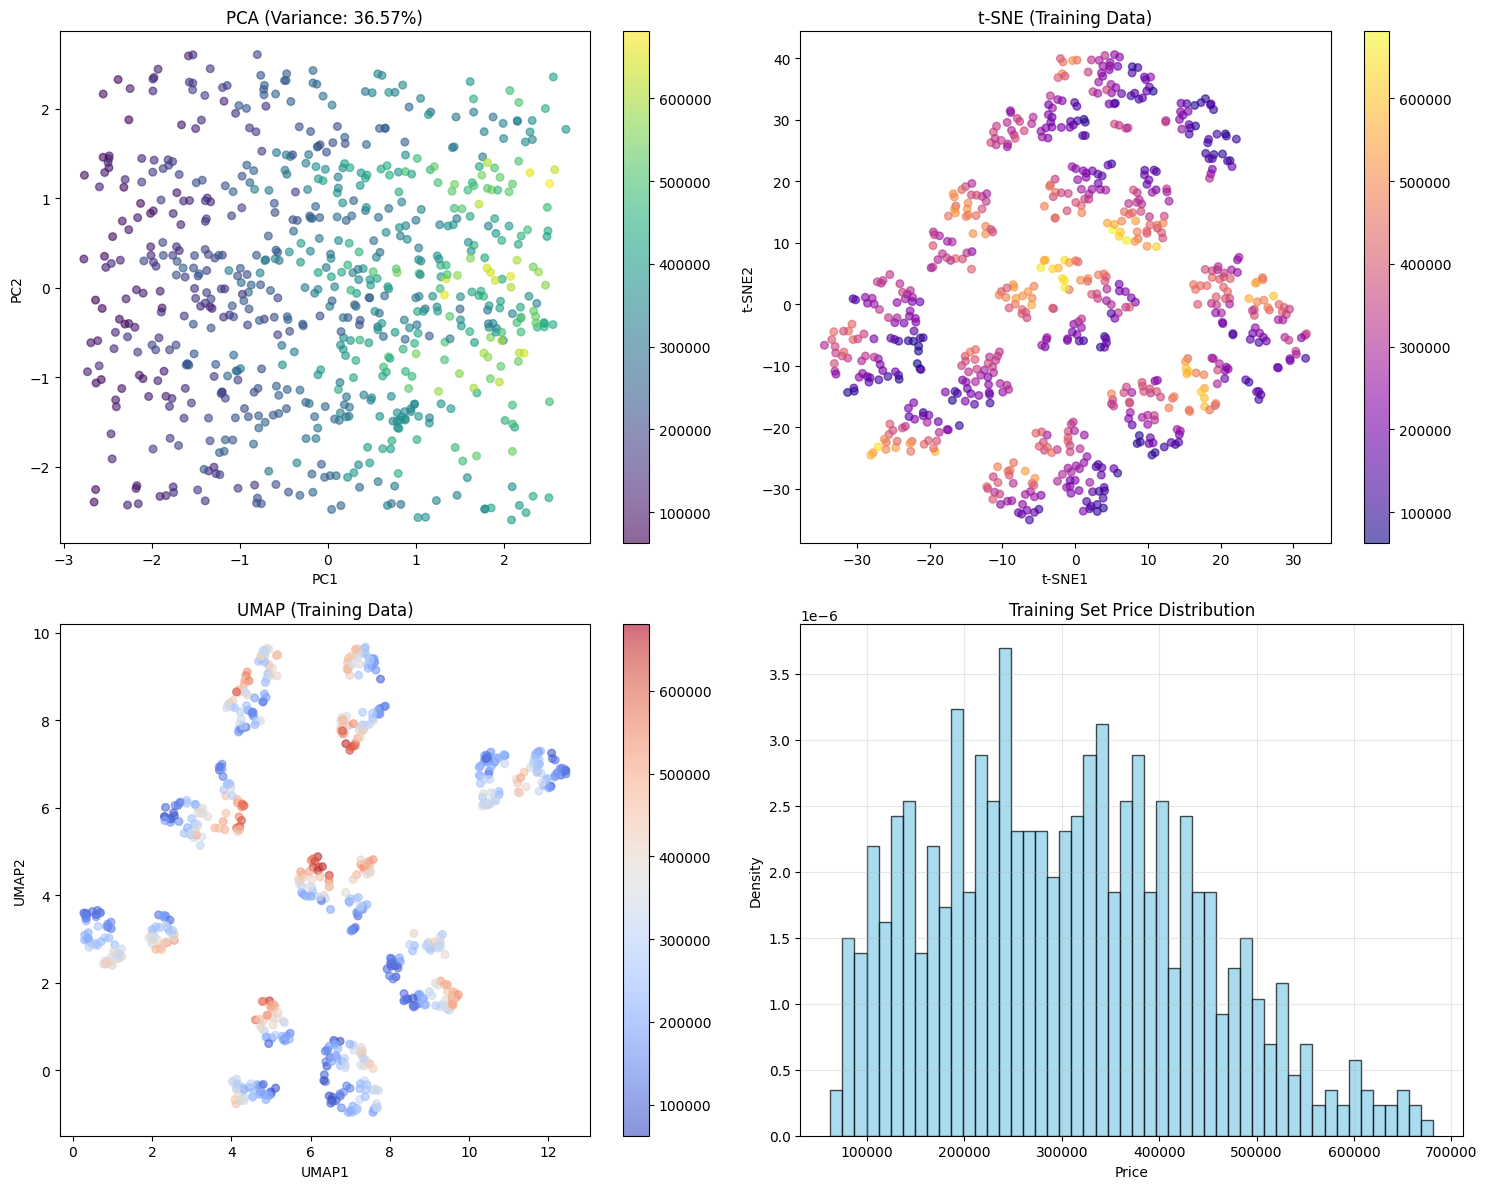


ADVANCED PCA ANALYSIS


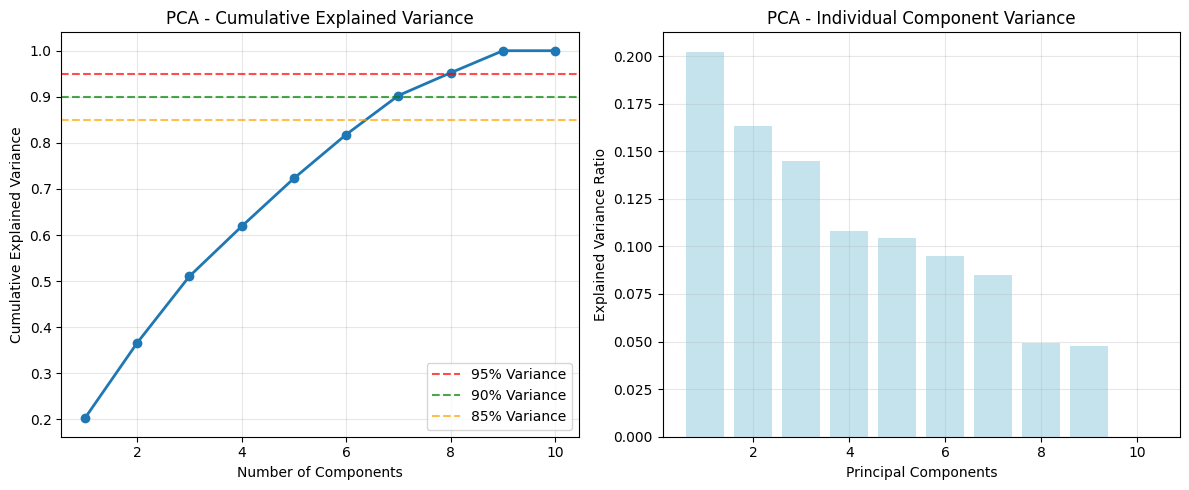

Components needed for 85% variance: 7
Components needed for 90% variance: 7
Components needed for 95% variance: 8

SAVING REDUCED DIMENSION DATASETS
Reduced features training set shape: (700, 5)
Reduced features test set shape: (300, 5)

Reduced features columns: ['PC1', 'PC2', 'UMAP1', 'UMAP2', 'Price']

✅ Dimensionality reduction completed successfully!
📊 Techniques applied: PCA, t-SNE, and UMAP
💾 Reduced dimension datasets are ready for modeling


In [ ]:
# 5️⃣ Dimensionality Reduction: PCA, t-SNE, and UMAP

# First, let's prepare the scaled data for dimensionality reduction
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Training data shape:", X_train_scaled.shape)
print("Feature names:", X_train_scaled_df.columns.tolist())

# A) PCA - Principal Component Analysis
print("\n" + "="*50)
print("PCA ANALYSIS")
print("="*50)

# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Create PCA DataFrames
pca_train_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
pca_train_df['Price'] = y_train.values
pca_train_df['Dataset'] = 'Train'

pca_test_df = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])
pca_test_df['Price'] = y_test.values
pca_test_df['Dataset'] = 'Test'

pca_combined_df = pd.concat([pca_train_df, pca_test_df], axis=0)

# Plot PCA results
plt.figure(figsize=(15, 5))

# Plot 1: PCA Scatter plot
plt.subplot(1, 3, 1)
scatter = plt.scatter(pca_combined_df['PC1'], pca_combined_df['PC2'], 
                     c=pca_combined_df['Price'], cmap='viridis', 
                     alpha=0.6, s=30)
plt.colorbar(scatter, label='Price')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - House Price Visualization')

# Plot 2: Explained Variance
plt.subplot(1, 3, 2)
explained_variance = pca.explained_variance_ratio_
components = range(1, len(explained_variance) + 1)
plt.bar(components, explained_variance, alpha=0.7, color=['skyblue', 'lightcoral'])
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title(f'PCA Explained Variance\nTotal: {sum(explained_variance):.2%}')

# Plot 3: Train vs Test separation
plt.subplot(1, 3, 3)
for dataset in ['Train', 'Test']:
    subset = pca_combined_df[pca_combined_df['Dataset'] == dataset]
    plt.scatter(subset['PC1'], subset['PC2'], 
               label=dataset, alpha=0.6, s=30)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - Train vs Test Data')
plt.legend()

plt.tight_layout()
plt.show()

print(f"PCA Explained Variance Ratio: {explained_variance}")
print(f"Total Variance Explained by 2 components: {sum(explained_variance):.2%}")

# B) t-SNE - t-Distributed Stochastic Neighbor Embedding
print("\n" + "="*50)
print("t-SNE ANALYSIS")
print("="*50)

# Apply t-SNE (only on training data for efficiency)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_train_tsne = tsne.fit_transform(X_train_scaled)

# Create t-SNE DataFrame
tsne_df = pd.DataFrame(X_train_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Price'] = y_train.values

# Plot t-SNE results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(tsne_df['TSNE1'], tsne_df['TSNE2'], 
                     c=tsne_df['Price'], cmap='plasma', alpha=0.7, s=30)
plt.colorbar(scatter, label='Price')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE - House Price Visualization (Training Data)')

plt.subplot(1, 2, 2)
# Color by price quartiles for better pattern recognition
tsne_df['Price_Quartile'] = pd.qcut(tsne_df['Price'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
colors = {'Q1': 'blue', 'Q2': 'green', 'Q3': 'orange', 'Q4': 'red'}
for quartile, color in colors.items():
    subset = tsne_df[tsne_df['Price_Quartile'] == quartile]
    plt.scatter(subset['TSNE1'], subset['TSNE2'], 
               c=color, label=quartile, alpha=0.7, s=30)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE - Price Quartiles')
plt.legend()

plt.tight_layout()
plt.show()

# C) UMAP - Uniform Manifold Approximation and Projection
print("\n" + "="*50)
print("UMAP ANALYSIS")
print("="*50)

# Apply UMAP
umap_reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_train_umap = umap_reducer.fit_transform(X_train_scaled)
X_test_umap = umap_reducer.transform(X_test_scaled)

# Create UMAP DataFrames
umap_train_df = pd.DataFrame(X_train_umap, columns=['UMAP1', 'UMAP2'])
umap_train_df['Price'] = y_train.values
umap_train_df['Dataset'] = 'Train'

umap_test_df = pd.DataFrame(X_test_umap, columns=['UMAP1', 'UMAP2'])
umap_test_df['Price'] = y_test.values
umap_test_df['Dataset'] = 'Test'

umap_combined_df = pd.concat([umap_train_df, umap_test_df], axis=0)

# Plot UMAP results
plt.figure(figsize=(15, 5))

# Plot 1: UMAP with continuous price coloring
plt.subplot(1, 3, 1)
scatter = plt.scatter(umap_combined_df['UMAP1'], umap_combined_df['UMAP2'], 
                     c=umap_combined_df['Price'], cmap='coolwarm', 
                     alpha=0.6, s=30)
plt.colorbar(scatter, label='Price')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP - House Price Visualization')

# Plot 2: Train vs Test in UMAP space
plt.subplot(1, 3, 2)
for dataset in ['Train', 'Test']:
    subset = umap_combined_df[umap_combined_df['Dataset'] == dataset]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], 
               label=dataset, alpha=0.6, s=30)
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP - Train vs Test Data')
plt.legend()

# Plot 3: UMAP with price categories
plt.subplot(1, 3, 3)
umap_combined_df['Price_Category'] = pd.cut(umap_combined_df['Price'], 
                                           bins=3, 
                                           labels=['Low', 'Medium', 'High'])
for category, color in zip(['Low', 'Medium', 'High'], ['blue', 'green', 'red']):
    subset = umap_combined_df[umap_combined_df['Price_Category'] == category]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], 
               c=color, label=category, alpha=0.6, s=30)
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP - Price Categories')
plt.legend()

plt.tight_layout()
plt.show()

# 6️⃣ Comparative Analysis of All Techniques
print("\n" + "="*50)
print("COMPARATIVE ANALYSIS")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# PCA
sc1 = axes[0, 0].scatter(pca_train_df['PC1'], pca_train_df['PC2'], 
                        c=pca_train_df['Price'], cmap='viridis', alpha=0.6, s=30)
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].set_title(f'PCA (Variance: {sum(explained_variance):.2%})')
plt.colorbar(sc1, ax=axes[0, 0])

# t-SNE
sc2 = axes[0, 1].scatter(tsne_df['TSNE1'], tsne_df['TSNE2'], 
                        c=tsne_df['Price'], cmap='plasma', alpha=0.6, s=30)
axes[0, 1].set_xlabel('t-SNE1')
axes[0, 1].set_ylabel('t-SNE2')
axes[0, 1].set_title('t-SNE (Training Data)')
plt.colorbar(sc2, ax=axes[0, 1])

# UMAP
sc3 = axes[1, 0].scatter(umap_train_df['UMAP1'], umap_train_df['UMAP2'], 
                        c=umap_train_df['Price'], cmap='coolwarm', alpha=0.6, s=30)
axes[1, 0].set_xlabel('UMAP1')
axes[1, 0].set_ylabel('UMAP2')
axes[1, 0].set_title('UMAP (Training Data)')
plt.colorbar(sc3, ax=axes[1, 0])

# Price distribution
axes[1, 1].hist(y_train, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
axes[1, 1].set_xlabel('Price')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Training Set Price Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7️⃣ Advanced PCA Analysis - Finding Optimal Components
print("\n" + "="*50)
print("ADVANCED PCA ANALYSIS")
print("="*50)

# Find optimal number of components
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate explained variance
explained_variance_ratio_full = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio_full)

# Plot explained variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='o', linewidth=2, markersize=6)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance', alpha=0.7)
plt.axhline(y=0.90, color='g', linestyle='--', label='90% Variance', alpha=0.7)
plt.axhline(y=0.85, color='orange', linestyle='--', label='85% Variance', alpha=0.7)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Individual explained variance
plt.bar(range(1, len(explained_variance_ratio_full) + 1), 
        explained_variance_ratio_full, alpha=0.7, color='lightblue')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Individual Component Variance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal components for different variance thresholds
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Components needed for 85% variance: {n_components_85}")
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")

# 8️⃣ Save the reduced dimension datasets for future use
print("\n" + "="*50)
print("SAVING REDUCED DIMENSION DATASETS")
print("="*50)

# Create DataFrames with reduced dimensions
reduced_features_train = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'UMAP1': X_train_umap[:, 0],
    'UMAP2': X_train_umap[:, 1],
    'Price': y_train.values
})

reduced_features_test = pd.DataFrame({
    'PC1': X_test_pca[:, 0],
    'PC2': X_test_pca[:, 1],
    'UMAP1': X_test_umap[:, 0],
    'UMAP2': X_test_umap[:, 1],
    'Price': y_test.values
})

print("Reduced features training set shape:", reduced_features_train.shape)
print("Reduced features test set shape:", reduced_features_test.shape)
print("\nReduced features columns:", reduced_features_train.columns.tolist())

print("\n✅ Dimensionality reduction completed successfully!")
print("📊 Techniques applied: PCA, t-SNE, and UMAP")
print("💾 Reduced dimension datasets are ready for modeling")